In [1]:
# Set autoreload
%load_ext autoreload
%autoreload 2

In [ ]:
# Import libraries
import warnings
import pandas as pd
import numpy as np
import sys; sys.path.insert(0, '..')

from CHAID import Tree
from src.back_testing import segment_summary
from src.plot_function import plot_roc, plot_ks, plot_classification_monthly, plot_stability_monthly, plot_segment_odr
from src.segment_support import cohort_count

warnings.simplefilter(action ='ignore', category = pd.errors.PerformanceWarning)
warnings.filterwarnings('ignore', category = RuntimeWarning)
warnings.filterwarnings('ignore', category = UserWarning)

In [3]:
# Import data
df = pd.read_parquet(
    '../data/processed/train_data.parquet',
    engine = 'pyarrow'
)

# Show table
df.head(5)

,APPLICATION_NUMBER,BRANCH,RESTRUCTURE_FLAG,pay_types,bal,CONTRACT_STATUS,TOTAL_TERM,OVERDUE_DAYS,CONTRACT_ID,CUSTOMER_NUMBER,...,avg_pay_9_to_due,max_ovd_6_to_fin,max_del_3,min_due_9_to_fin,score_from_model,score_band,def,ever_default_12,lifetime_flag,times
13915,A-A829614,A,N,1,992664.0,10,72.0,0,2416423,5543426,...,0.000000,NaN,NaN,NaN,NaN,NaN,0,0,1,41
13916,A-A829614,A,N,2,978877.0,10,72.0,0,2416423,5543426,...,0.000000,0.000000,0.0,0.018681,526.0,B4,0,0,1,40
13917,A-A829614,A,N,1,978877.0,21,72.0,26,2416423,5543426,...,0.055556,0.000000,0.0,0.018681,526.0,B4,0,0,1,39
13918,A-A829614,A,N,1,978877.0,41,72.0,56,2416423,5543426,...,0.037037,0.018681,1.0,0.018681,277.0,B6,0,0,1,38
13919,A-A829614,A,N,2,951303.0,41,72.0,26,2416423,5543426,...,0.055556,0.037362,2.0,0.018681,226.0,B6,0,0,1,37


In [4]:
# Simple manual re-binning --> (Not full analysis)
# Features: TOTAL_TERM
def re_group(feature):
    if feature <= 60:   return "Term<=60"
    elif feature > 60:  return "Term>60"
    else: return np.nan

# Assign adjusted segmentation
func = np.vectorize(re_group)
bins = func(df['TOTAL_TERM'])
df['total_term'] = bins

In [5]:
# Features: MOB
def re_group(feature):
    if feature <= 6:   return "MOB<=6"
    elif feature > 6:  return "MOB>6"
    else: return np.nan

# Assign adjusted segmentation
func = np.vectorize(re_group)
bins = func(df['MOB'])
df['mob'] = bins

In [6]:
# CHAID Columns
cols = [
    'del',
    'score_band',
    'fin',
    'total_term',
    'mob',
    'ever_default_12' #Target
]

# Data selection
train = df[cols]

In [7]:
# CHAID Segmentation
tree = Tree.from_pandas_df(
    train,
    {
        'del': 'nominal',
        'score_band': 'nominal',
        'total_term': 'nominal',
        'mob': 'nominal'
    },
    'ever_default_12',
    min_parent_node_size = 0.05
)

# Print CHAID Tree result
tree.print_tree()

([], {0: 564044.0, 1: 27384.0}, (del, p=0.0, score=96264.31706392032, groups=[[0], [1], [2], [3]]), dof=3))
|-- ([0], {0: 408873.0, 1: 5374.0}, (score_band, p=0.0, score=11425.873754868097, groups=[['<missing>'], ['B6'], ['B7'], ['B1'], ['B5'], ['B8'], ['B2'], ['B4'], ['B3']]), dof=8))
|   |-- (['<missing>'], {0: 20685.0, 1: 1165.0}, <Invalid Chaid Split> - the minimum parent node size threshold has been reached)
|   |-- (['B6'], {0: 4617.0, 1: 480.0}, <Invalid Chaid Split> - the minimum parent node size threshold has been reached)
|   |-- (['B7'], {0: 771.0, 1: 214.0}, <Invalid Chaid Split> - the minimum parent node size threshold has been reached)
|   |-- (['B1'], {0: 100841.0, 1: 220.0}, <Invalid Chaid Split> - the max depth has been reached)
|   |-- (['B5'], {0: 14084.0, 1: 457.0}, <Invalid Chaid Split> - the minimum parent node size threshold has been reached)
|   |-- (['B8'], {0: 27.0, 1: 18.0}, <Invalid Chaid Split> - the minimum parent node size threshold has been reached)
|   

In [8]:
# CHAID output is not used --> Manual override segmemtation
def segment_assign(mob, score, bucket):
    if mob <= 6 and bucket == 0             :return 'segment_0'
    elif mob <= 6 and bucket == 1           :return 'segment_1'
    elif mob <= 6 and bucket == 2           :return 'segment_2'
    elif mob <= 6 and bucket == 3           :return 'segment_3'
    elif mob > 6 and score == 'B1'          :return 'segment_4'
    elif mob > 6 and score == 'B2'          :return 'segment_5'
    elif mob > 6 and score == 'B3'          :return 'segment_6'
    elif mob > 6 and score == 'B4'          :return 'segment_7'
    elif mob > 6 and score == 'B5'          :return 'segment_8'
    elif mob > 6 and score == 'B6'          :return 'segment_9'
    elif mob > 6 and score == 'B7'          :return 'segment_10'
    elif mob > 6 and score == 'B8'          :return 'segment_11'
    else                                    :return np.nan

# Assign adjusted segmentation
func = np.vectorize(segment_assign)
segment = func(df['MOB'], df['score_band'], df['del'])
df['segment'] = segment

In [ ]:
# Segmentation summary as 12-months unbias ODR
unbias_odr = segment_summary(bin_labels = df['segment'], y_true = df['ever_default_12'])

# Export
unbias_odr.to_parquet(
    "../data/processed/unbias_odr.parquet",
    engine = 'pyarrow'
)

# Show table
unbias_odr

,segment,n,bad,odr,good,cum_bad,cum_good,roc,ks
5,segment_3,739,640,0.866035,99.0,0.023371,0.000176,0.000002,0.023196
3,segment_11,4531,2432,0.536747,2099.0,0.112182,0.003897,0.000252,0.108285
4,segment_2,3494,1625,0.465083,1869.0,0.171524,0.007210,0.000470,0.164313
2,segment_10,26408,7365,0.278893,19043.0,0.440476,0.040972,0.010331,0.399504
1,segment_1,18133,3135,0.172889,14998.0,0.554959,0.067562,0.013234,0.487397
11,segment_9,38786,4923,0.126927,33863.0,0.734736,0.127598,0.038714,0.607137
10,segment_8,55294,2090,0.037798,53204.0,0.811058,0.221924,0.072904,0.589133
0,segment_0,125102,3595,0.028737,121507.0,0.942339,0.437345,0.188859,0.504993
9,segment_7,58612,804,0.013717,57808.0,0.971699,0.539834,0.098083,0.431865
8,segment_6,79047,366,0.004630,78681.0,0.985064,0.679328,0.136479,0.305736


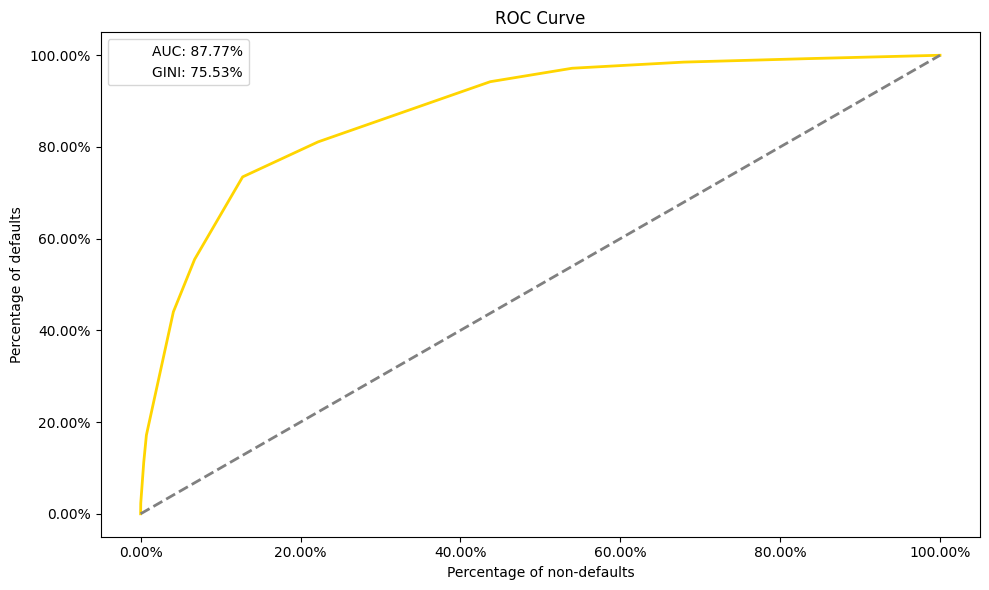

In [10]:
# Back-testing --> Classification ability (Portfolio level)
# Plot ROC
plot_roc(
    cum_good = unbias_odr['cum_good'],
    cum_bad = unbias_odr['cum_bad']
)

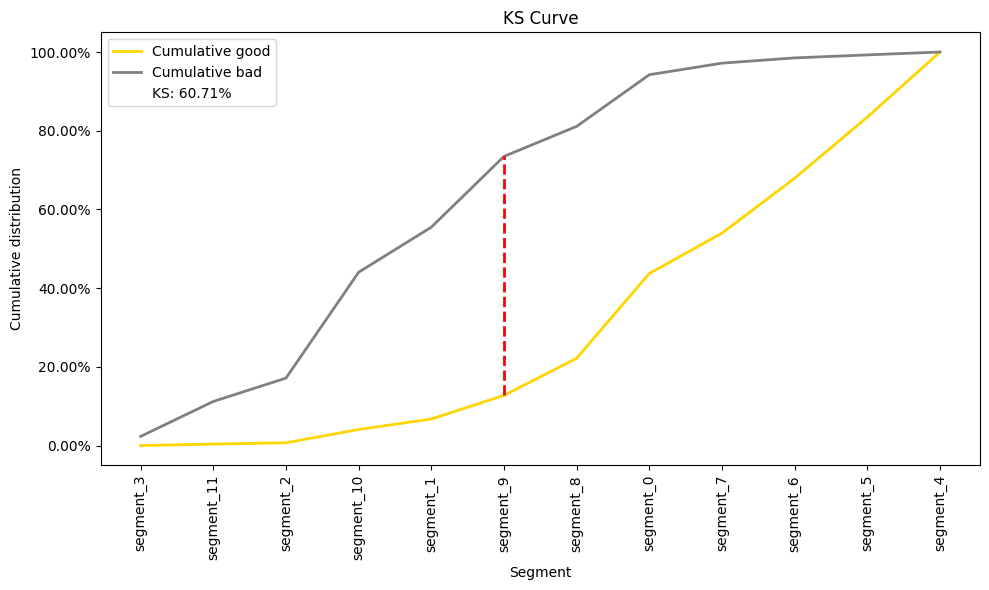

In [11]:
# Plot KS
plot_ks(
    bin_labels = unbias_odr['segment'],
    cum_good = unbias_odr['cum_good'],
    cum_bad = unbias_odr['cum_bad']
)

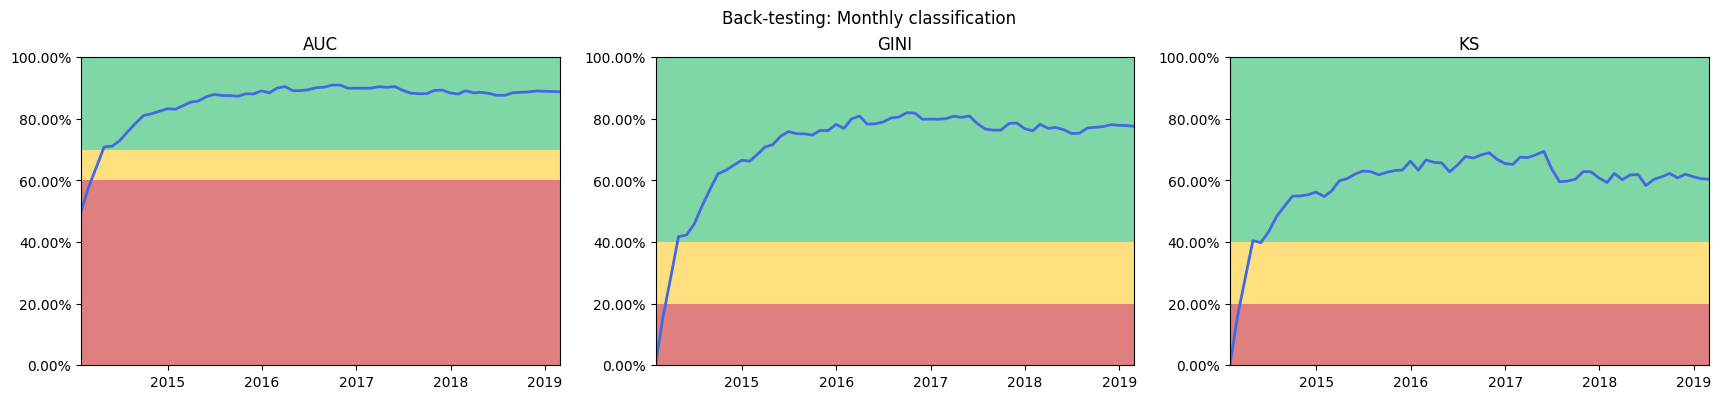

In [12]:
# Back-testing --> Classification ability (Monthly level)
plot_classification_monthly(
    month = df['AS_OF_DATE'],
    bin_labels = df['segment'],
    y_true = df['ever_default_12'],
)

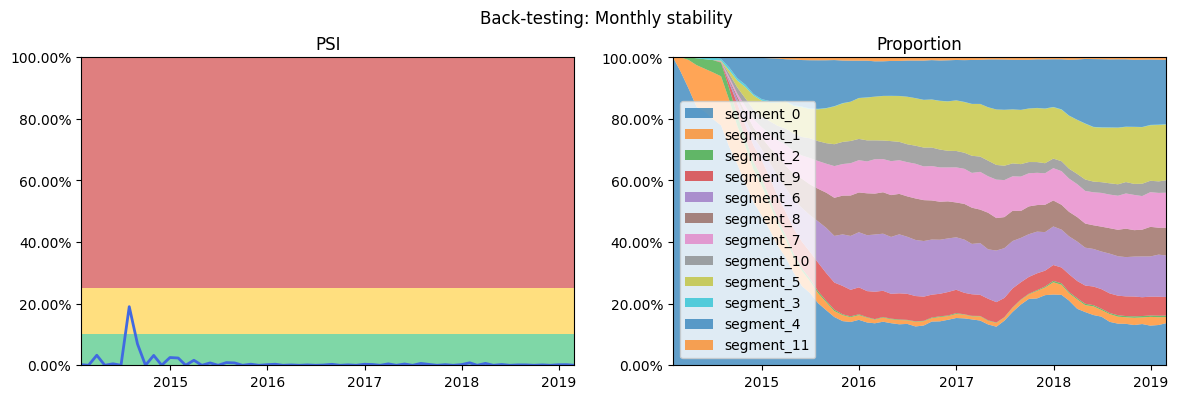

In [13]:
# Back-testing --> Stability (Monthly level)
plot_stability_monthly(
    month = df['AS_OF_DATE'],
    bin_labels = df['segment'],
    y_true = df['ever_default_12'],
)

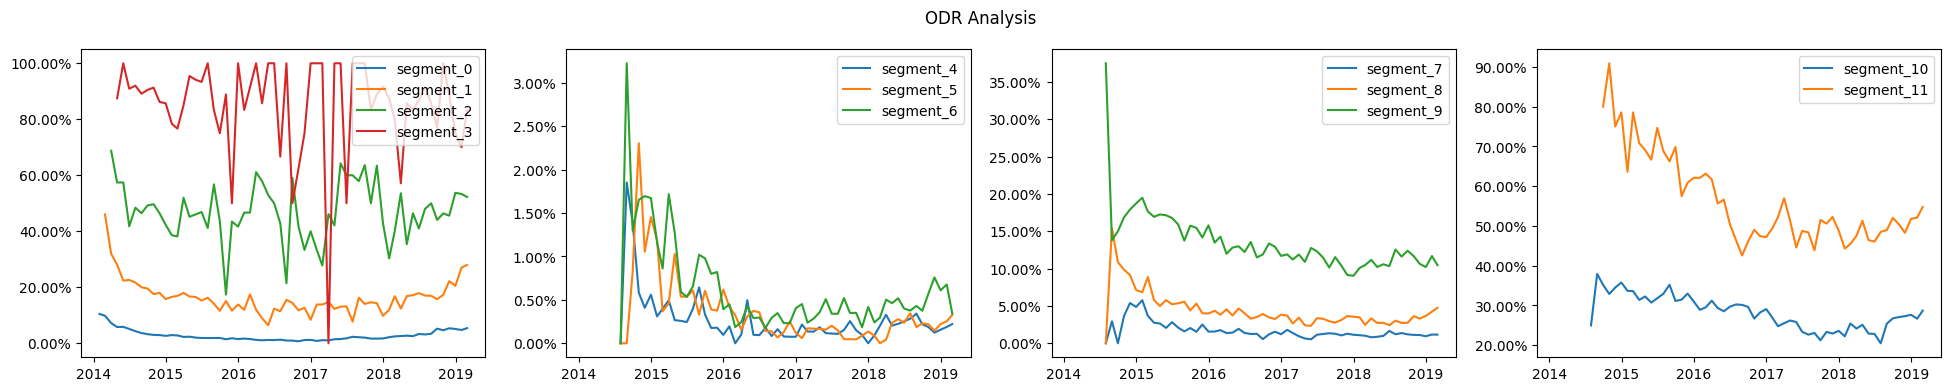

In [14]:
# Back-testing --> ODR (Monthly level)
pool = [
    ["segment_0", "segment_1", "segment_2", "segment_3"],
    ["segment_4", "segment_5", "segment_6"],
    ["segment_7", "segment_8", "segment_9"],
    ["segment_10", "segment_11",]
]

plot_segment_odr(
    month = df['AS_OF_DATE'],
    bin_labels = df['segment'],
    y_true = df['ever_default_12'],
    pool = pool
)

In [15]:
# Cohort count and export
cohort_count(
    segment_col = df['segment'],
    period_col = df['AS_OF_DATE'],
    lifetime_col = df['times'],
    default_col = df['lifetime_flag']
)

=== Processing ===
[Cohort count]
=== Result ===
[Export location: '..data/processed/cohort_count.parquet']
